In [2]:
#imports
from graphviz import Digraph
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# DAG Function
def create_dag(title, psychosis, weight_gain, citalopram, remission, age, female):
    g = Digraph()

    # Title of the graph
    g.graph_attr.update(
        label=title,
        labelloc='t',
        fontsize='18',
        fontcolor='blue'
    )

    # Node style (Netica-like)
    g.attr('node', shape='box', style='filled', fillcolor='lightyellow')

    # Nodes with probabilities
    g.node('Psychosis', f'Psychosis\n\nYes {psychosis[0]}\nNo {psychosis[1]}')
    g.node('WeightGain', f'Weight Gain\n\nYes {weight_gain[0]}\nNo {weight_gain[1]}')
    g.node('Citalopram', f'Citalopram\n\nYes {citalopram[0]}\nNo {citalopram[1]}')
    g.node('Remission', f'Remission\n\nYes {remission[0]}\nNo {remission[1]}')
    g.node('Age', f'Age > 30\n\nYes {age[0]}\nNo {age[1]}')
    g.node('Female', f'Female\n\nYes {female[0]}\nNo {female[1]}')

    # Causal edges (structure of the DAG)
    g.edge('Psychosis', 'WeightGain')
    g.edge('WeightGain', 'Remission')
    g.edge('Citalopram', 'WeightGain')
    g.edge('Citalopram', 'Remission')
    g.edge('Age', 'Citalopram')
    g.edge('Female', 'Citalopram')
    g.edge('Age', 'Remission')
    g.edge('Female', 'Remission')
    g.edge('Age', 'Psychosis')

    return g

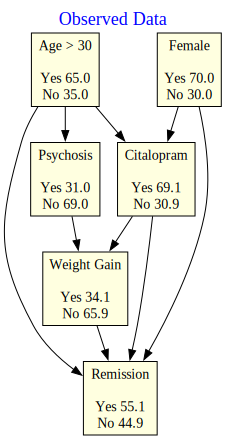

In [5]:
# Observed Data DAG
# This represents the observational (non-intervened) distribution

g_obs = create_dag(
    title="Observed Data",
    psychosis=(31.0, 69.0),
    weight_gain=(34.1, 65.9),
    citalopram=(69.1, 30.9),
    remission=(55.1, 44.9),
    age=(65.0, 35.0),     # P(Age > 30) = 0.65
    female=(70.0, 30.0)   # P(Female) = 0.70
)

display(g_obs)

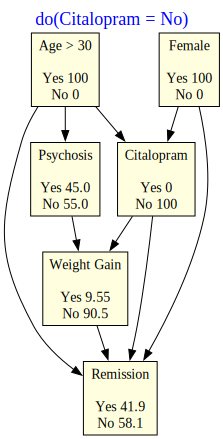

In [6]:
# intervention do(Citalopram = No)
# This represents intervention: forcing treatment = No (do(T=0))

g_no = create_dag(
    title="do(Citalopram = No)",
    psychosis=(45.0, 55.0),
    weight_gain=(9.55, 90.5),
    citalopram=(0, 100),   # Intervention: 100% untreated
    remission=(41.9, 58.1),
    age=(100, 0),          # Fixing a stratum (Age > 30)
    female=(100, 0)        # Fixing a stratum (Female)
)

display(g_no)

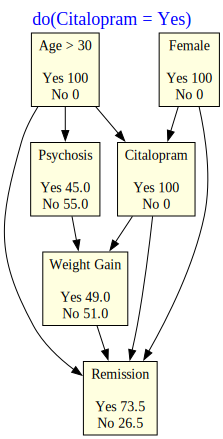

In [7]:
# Intervention do(Citalopram = Yes)
# This represents intervention: forcing treatment = Yes (do(T=1))

g_yes = create_dag(
    title="do(Citalopram = Yes)",
    psychosis=(45.0, 55.0),
    weight_gain=(49.0, 51.0),
    citalopram=(100, 0),   # Intervention: 100% treated
    remission=(73.5, 26.5),
    age=(100, 0),
    female=(100, 0)
)

display(g_yes)

In [8]:
# Stratified Treatment Effects
# Each stratum = subgroup defined by Age and Gender
# Values are P(Remission | do(T=1)) and P(Remission | do(T=0))

strata = {
    "Age>30_Female": {"treated": 73.5, "untreated": 41.9},   #1st stratum
    "Age>30_Male":   {"treated": 61.3, "untreated": 11.9},   #2nd stratum
    "Age<=30_Female":{"treated": 79.6, "untreated": 30.4},   #3rd stratum
    "Age<=30_Male":  {"treated": 49.6, "untreated": 1.37}    #4th stratum
}

In [9]:
# Marginal Probabilities
# Probability that a randomly selected patient is older than 30
P_age_gt_30 = 0.65

# Probability that a randomly selected patient is 30 or younger
P_age_le_30 = 0.35

# Probability that a randomly selected patient is female
P_female = 0.70

# Probability that a randomly selected patient is male
P_male = 0.30

In [10]:
# Joint Probabilities (Independence Assumption)
# Assuming Age and Gender are independent:
# P(Age AND Gender) = P(Age) * P(Gender)

probs = {
    "Age>30_Female": P_age_gt_30 * P_female,
    "Age>30_Male":   P_age_gt_30 * P_male,
    "Age<=30_Female":P_age_le_30 * P_female,
    "Age<=30_Male":  P_age_le_30 * P_male
}

probs

{'Age>30_Female': 0.45499999999999996,
 'Age>30_Male': 0.195,
 'Age<=30_Female': 0.24499999999999997,
 'Age<=30_Male': 0.105}

In [12]:
# Average Treatment Effect (ATE) per Stratum
# ATE within each subgroup = treated - untreated

ate_per_strata = {}

for k, v in strata.items():
    ate_per_strata[k] = v["treated"] - v["untreated"]

ate_per_strata

{'Age>30_Female': 31.6,
 'Age>30_Male': 49.4,
 'Age<=30_Female': 49.199999999999996,
 'Age<=30_Male': 48.230000000000004}

In [13]:
# Weighted Average Treatment Effect
# Standardization formula:
# ATE = sum over strata of P(stratum) * ATE(stratum)

weighted_ate = sum(probs[k] * ate_per_strata[k] for k in strata)

print(f"Final Weighted ATE = {weighted_ate:.2f}%")

Final Weighted ATE = 41.13%


In [15]:
# table Output
df = pd.DataFrame({
    "Strata": list(strata.keys()),
    "Probability": [round(probs[k], 2) for k in strata.keys()],
    "ATE": [round(ate_per_strata[k], 2) for k in strata.keys()]
})

df

,Strata,Probability,ATE
0,Age>30_Female,0.45,31.60
1,Age>30_Male,0.20,49.40
2,Age<=30_Female,0.24,49.20
3,Age<=30_Male,0.10,48.23


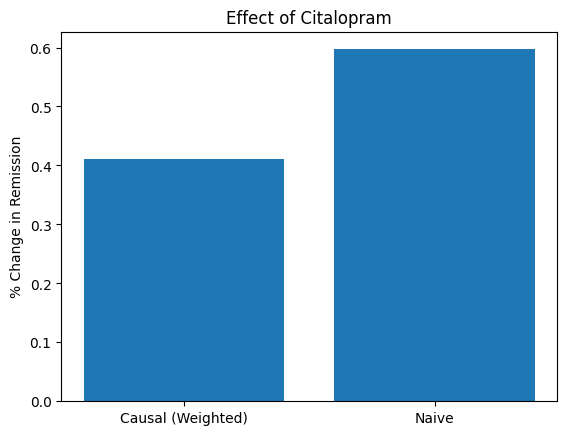

In [16]:
# Visualization
# Compare causal estimate vs naive estimate

labels = ["Causal (Weighted)", "Naive"]

# Convert percentages to proportions for plotting
causal_effect = weighted_ate / 100

# Naive effect ignores confounding
naive_effect = (73.5 - 13.8) / 100

values = [causal_effect, naive_effect]

plt.figure()
plt.bar(labels, values)

plt.ylabel("% Change in Remission")
plt.title("Effect of Citalopram")

plt.show()